> **Task**: Build a machine learning model to predict the selling price of a car based on features like age, mileage, fuel type, and transmission.
* Analyze, preprocess the dataset, train multiple regression models, and select the best-performing model for accurate price prediction.




> **Problem** **Statement**

The price of a car depends on multiple factors like:

* Brand value
* Mileage
* Engine power
* Fuel type
* Number of years used

The objective is to develop a machine learning model that predicts the selling price of a car based on these features.

>**Dataset Description**

The dataset contains information about used cars.

* Car_Name – Name of the car
* Year – Manufacturing year
* Selling_Price – Price (Target variable)
* Present_Price – Current showroom price
* Driven_kms – Distance driven
* Fuel_Type – Petrol/Diesel/CNG
* Selling_type – Dealer/Individual
* Transmission – Manual/Automatic
* Owner – Number of previous owners

> **Libraries Required**

In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


> **Loading Dataset**

In [212]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


> **Exploring the Data**

In [213]:
df.keys()

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [214]:
type(df)

pandas.core.frame.DataFrame

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [216]:
df.shape

(301, 9)

In [217]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


> **Exploratory Data Analysis (EDA)**

In [218]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [219]:
df['Owner'].value_counts()

,count
Owner,
0,290
1,10
3,1


In [220]:
df['Selling_type'].value_counts()

,count
Selling_type,
Dealer,195
Individual,106


In [221]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [222]:
df.dropna(inplace=True)

In [223]:
df.drop(['Car_Name'], axis=1, inplace=True)

> **Visualization**



*   **Pairplot**



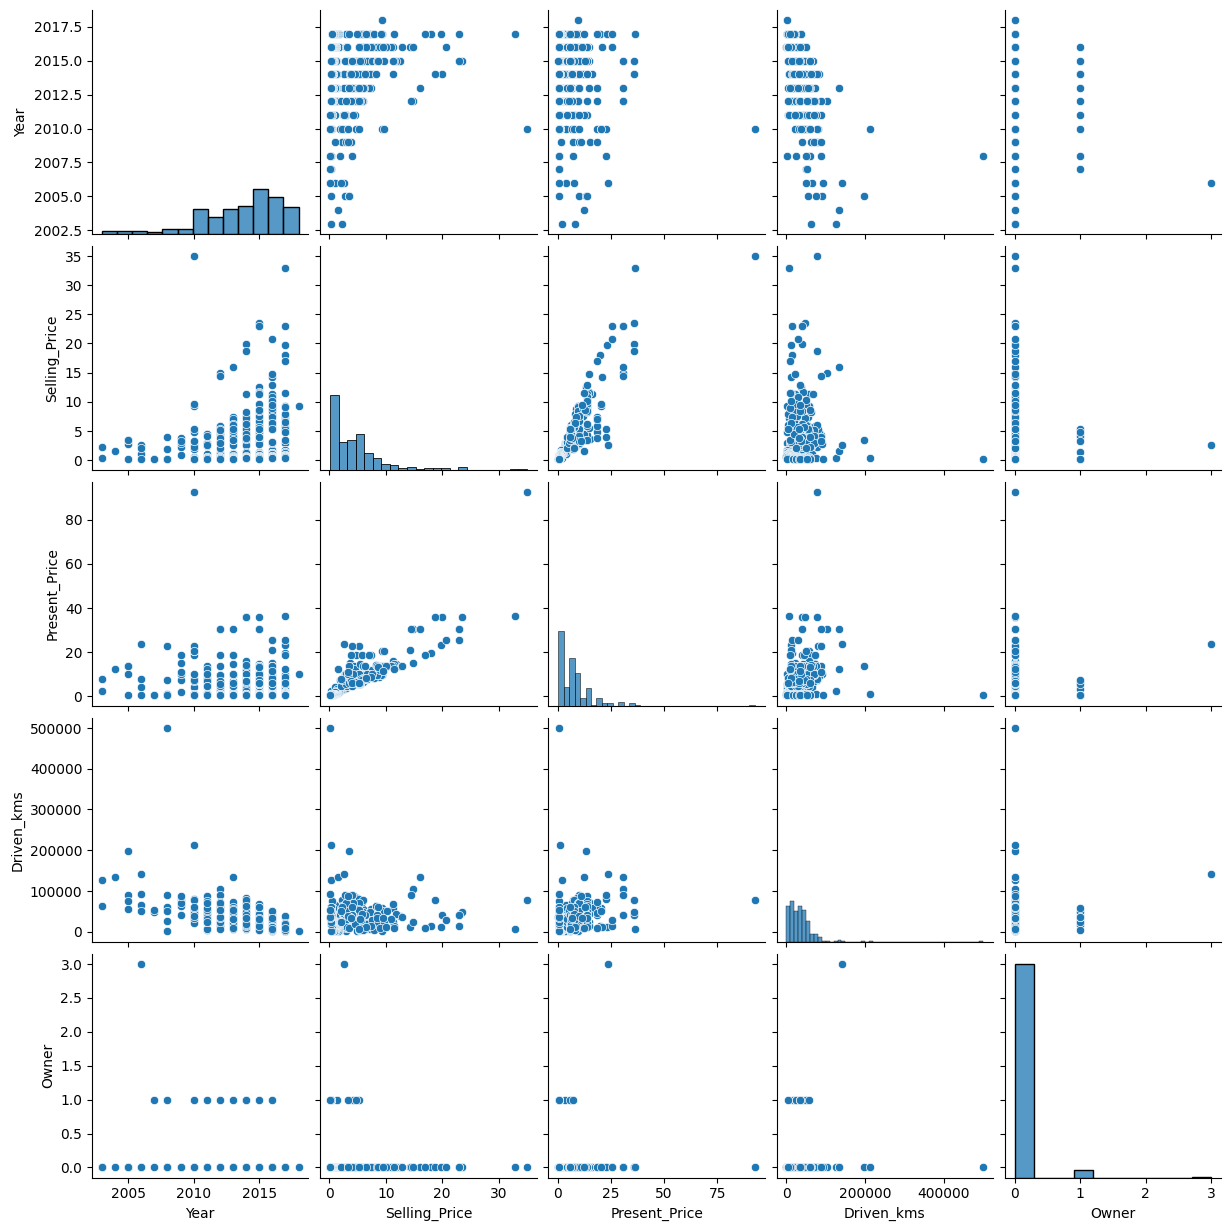

In [224]:
sns.pairplot(df)

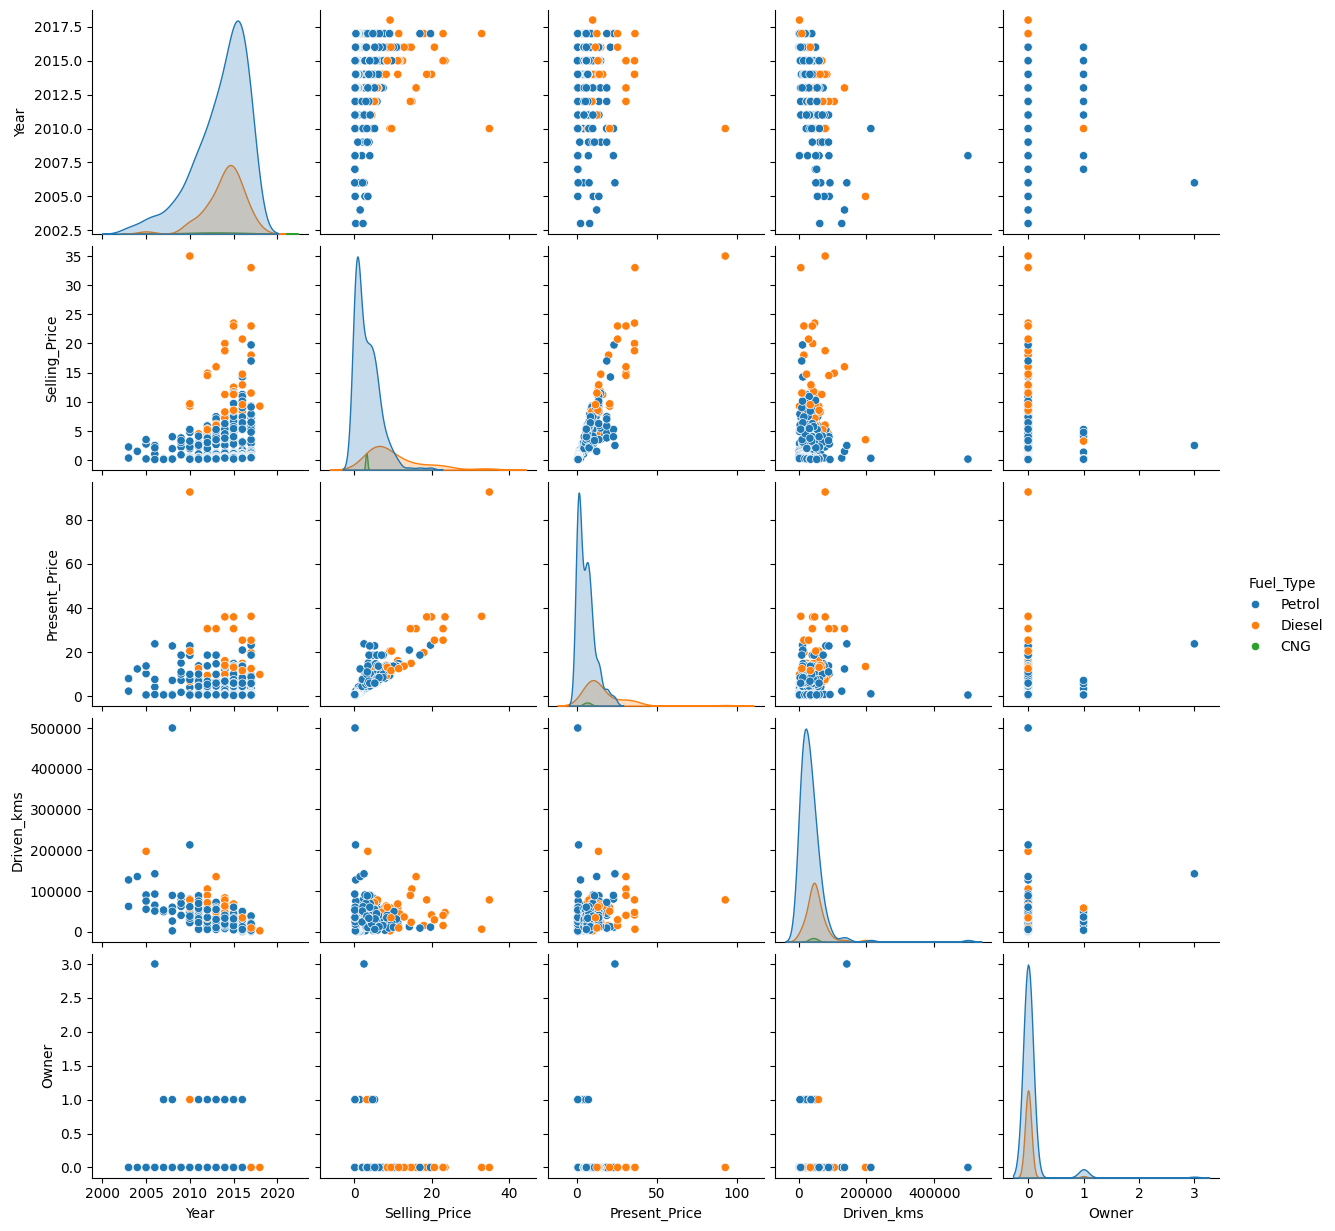

In [225]:
sns.pairplot(df, hue='Fuel_Type')



*   **Heatmap**


<Axes: >

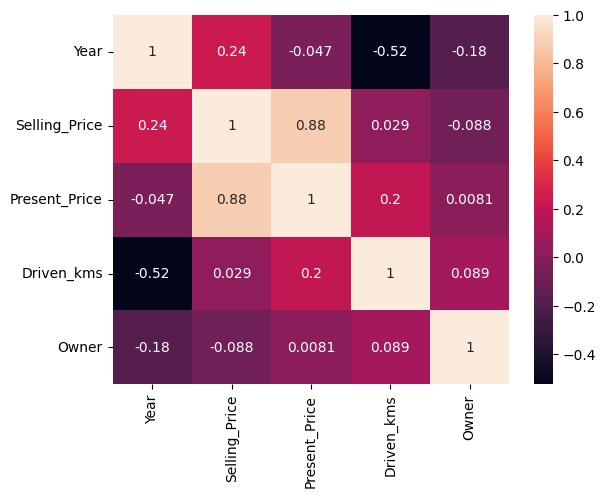

In [226]:
sns.heatmap(df.corr(numeric_only=True), annot=True)


> **Data Preprocessing**

In [227]:
df['Car_Age'] = 2026 - df['Year']
df.drop(['Year'], axis=1, inplace=True)

In [228]:
df = pd.get_dummies(df, drop_first=True)

In [229]:
df.drop(['Car_Name'], axis=1, inplace=True,errors='ignore')

In [230]:
df.isnull().sum()

,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Owner,0
Car_Age,0
Fuel_Type_Diesel,0
Fuel_Type_Petrol,0
Selling_type_Individual,0
Transmission_Manual,0


In [231]:
df.dropna(inplace=True)

In [232]:
df.fillna(df.mean(), inplace=True)

> **Splitting Data**

In [233]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [234]:
from sklearn.model_selection import train_test_split

X = df.drop('Selling_Price', axis=1)  # Features
y = df['Selling_Price']               # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

> **Model Training**

*   **Begginner level**

     Used Random Forest Regressor because it handles
     * non-linear relationships well
     * reduces overfitting using multiple trees
     * provides high accuracy with minimal tuning
     
      making it suitable for real-world datasets like car price prediction.


In [235]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

> **Model Evaluation**

In [236]:
y_pred = rf.predict(X_test)

In [237]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9594566919773236


> **Model Training (Advanced)**



1.   **Start with Baseline Models**

In [238]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(name, score)

Linear Regression 0.8488707839193155
Decision Tree 0.936320332598304
Random Forest 0.9554841970229158



2.   **Hyperparameter Tuning**



In [239]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}



3.   **Cross Validation**



In [240]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5)

print("Average R2:", scores.mean())

Average R2: 0.35041176415693365




4.**Final Evaluation**   


In [241]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.9564270702931321
RMSE: 1.0018622186005521


> **Random Samples from Test Data**

In [242]:
import random

# pick a random index
index = random.randint(0, len(X_test)-1)

sample = X_test.iloc[index]
actual_price = y_test.iloc[index]

# reshape for prediction
sample_reshaped = sample.values.reshape(1, -1)

pred = best_model.predict(X_test.iloc[[index]])

print("Car Features:\n", sample)
print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price[0])

Car Features:
 Present_Price               0.58
Driven_kms                 30000
Owner                          0
Car_Age                       13
Fuel_Type_Diesel           False
Fuel_Type_Petrol            True
Selling_type_Individual     True
Transmission_Manual         True
Name: 182, dtype: object
Actual Price: 0.3
Predicted Price: 1.1521


In [243]:
for i in range(5):
    index = random.randint(0, len(X_test)-1)

    sample = X_test.iloc[index]
    actual = y_test.iloc[index]

    pred = best_model.predict(X_test.iloc[[index]])
    print(f"\nSample {i+1}")
    print("Actual:", actual)
    print("Predicted:", pred[0])


Sample 1
Actual: 5.5
Predicted: 5.078376190476189

Sample 2
Actual: 8.35
Predicted: 7.857496336996343

Sample 3
Actual: 6.15
Predicted: 5.368096230158727

Sample 4
Actual: 0.5
Predicted: 0.5940986449661452

Sample 5
Actual: 3.75
Predicted: 3.512225388500387


> **Scores & Metrics**

In [ ]:
model.score(X_test, y_test)

In [244]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_pred = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9564270702931321
MAE: 0.6590632916468783
RMSE: 1.0018622186005521
